# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

### Business Problem

The goal of this project is to determine which characteristics have the greatest impact on the price of a used vehicle. 
Price will be treated as the target variable, while features such as year, mileage, manufacturer, model, condition, fuel type, and transmission will be examined as potential predictors.

I will use regression models to predict vehicle prices and determine which features have the strongest relationship with price. The results will then be 
translated into recommendations that can help a used car dealership make better inventory decisions.

### Data Exploration 

From a business perspective, we are tasked with identifying key drivers for used car prices. In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition. Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('vehicles.csv')
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [5]:
df_clean = df.drop(columns=[
    'id', 'VIN', 'url', 'region_url', 'image_url',
    'description', 'posting_date', 'lat', 'long'
], errors='ignore')

df_clean.shape

(426880, 16)

In [6]:
df_clean = df_clean.dropna(subset=['price', 'year', 'odometer'])

df_clean.isnull().sum().sort_values(ascending=False)

size            301612
cylinders       174759
condition       170493
drive           128849
paint_color     128090
type             91782
manufacturer     16267
title_status      7358
model             5195
fuel              2172
transmission      1695
year                 0
price                0
region               0
odometer             0
state                0
dtype: int64

In [7]:
df_clean = df_clean[
    (df_clean['price'] >= 1000) &
    (df_clean['price'] <= 100000) &
    (df_clean['odometer'] >= 0) &
    (df_clean['odometer'] <= 300000)
]

df_clean.shape

(374125, 16)

In [8]:
df_clean['vehicle_age'] = 2021 - df_clean['year']

df_clean[['price', 'year', 'vehicle_age', 'odometer']].describe()

,price,year,vehicle_age,odometer
count,374125.000000,374125.000000,374125.000000,374125.000000
mean,19335.198915,2011.051333,9.948667,91998.463241
std,14276.501590,9.495840,9.495840,61838.715344
min,1000.000000,1900.000000,-1.000000,0.000000
25%,7990.000000,2008.000000,4.000000,38355.000000
50%,15990.000000,2013.000000,8.000000,87280.000000
75%,27990.000000,2017.000000,13.000000,135000.000000
max,100000.000000,2022.000000,121.000000,300000.000000


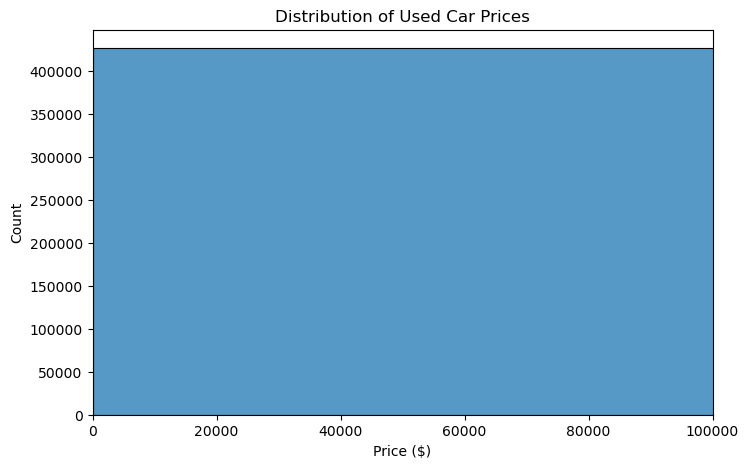

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=50)
plt.xlim(0, 100000)
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

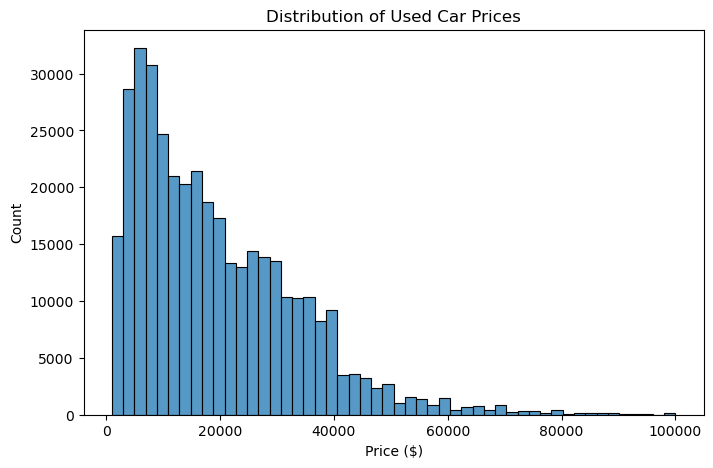

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(df_clean['price'], bins=50)

plt.title('Distribution of Used Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')

plt.show()

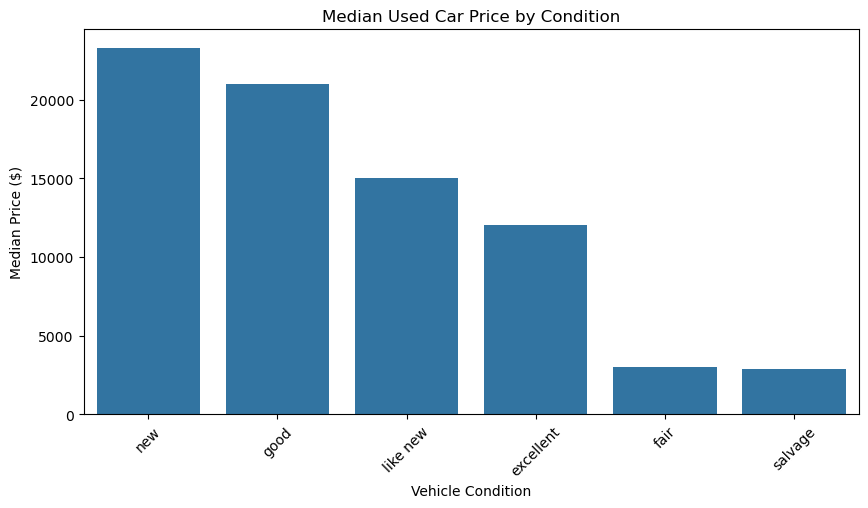

### Exploratory Data Analysis Findings

The visualizations show several patterns that are relevant to used vehicle pricing. Vehicle prices generally decrease as mileage increases, suggesting that odometer reading is an important factor in determining resale value. Vehicle condition also has a clear relationship with price, with new and good-condition vehicles having substantially higher median prices than fair or salvage vehicles.

These patterns suggest that mileage and condition should be important variables in the regression models, along with other characteristics such as manufacturer, year, fuel type, transmission, drivetrain, and vehicle type.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [9]:
features = [
    'year', 'odometer', 'manufacturer', 'condition',
    'fuel', 'transmission', 'drive', 'type'
]

model_df = df_clean[features + ['price']].copy()

X = model_df[features]
y = model_df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
numeric_features = ['year', 'odometer']
categorical_features = [
    'manufacturer', 'condition', 'fuel',
    'transmission', 'drive', 'type'
]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [11]:
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_cv = -cross_val_score(
    linear_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error'
).mean()

print("Linear Regression CV MAE:", linear_cv)

Linear Regression CV MAE: 6326.438019283149


In [12]:
ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_params = {
    'model__alpha': [0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_model,
    ridge_params,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best alpha:", ridge_grid.best_params_)
print("Ridge CV MAE:", -ridge_grid.best_score_)

Best alpha: {'model__alpha': 0.1}
Ridge CV MAE: 6326.6048688684


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [13]:
models = {
    'Linear Regression': linear_model,
    'Ridge Regression': ridge_grid.best_estimator_
}

results = []

for name, model in models.items():
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'RMSE', 'R²']
)

results_df

,Model,MAE,RMSE,R²
0,Linear Regression,6343.344055,9108.968754,0.594490
1,Ridge Regression,6343.377863,9108.097892,0.594567


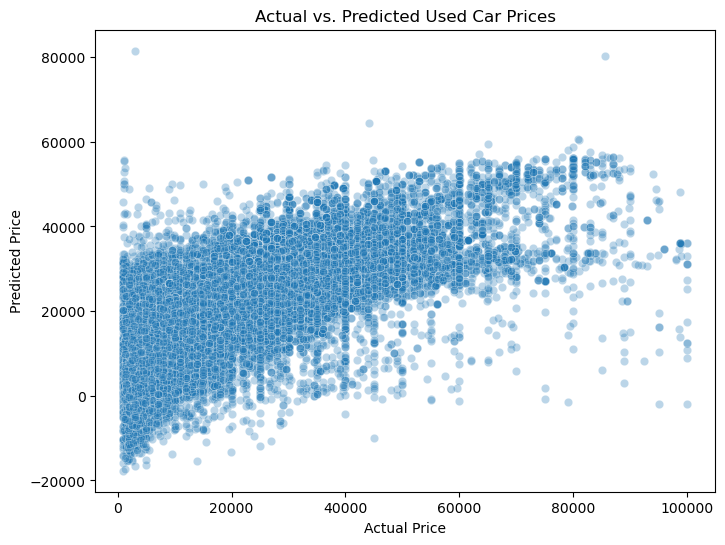

In [14]:
best_model = ridge_grid.best_estimator_
predictions = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.3)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted Used Car Prices')

plt.show()

In [15]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_model.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df['Absolute Coefficient'] = coef_df['Coefficient'].abs()

coef_df.sort_values(
    'Absolute Coefficient',
    ascending=False
).head(20)

,Feature,Coefficient,Absolute Coefficient
13,cat__manufacturer_ferrari,50437.609945,50437.609945
40,cat__manufacturer_tesla,16491.142739,16491.142739
4,cat__manufacturer_aston-martin,14482.246657,14482.246657
50,cat__fuel_diesel,12481.601576,12481.601576
17,cat__manufacturer_harley-davidson,-11930.948306,11930.948306
14,cat__manufacturer_fiat,-9956.842786,9956.842786
35,cat__manufacturer_porsche,9114.050907,9114.050907
31,cat__manufacturer_mitsubishi,-8830.992358,8830.992358
38,cat__manufacturer_saturn,-6972.106105,6972.106105
1,num__odometer,-6905.018588,6905.018588


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### Findings and Recommendations

The goal of this analysis was to identify the characteristics that help explain used vehicle prices and provide useful information for dealerships when selecting inventory.

Both Linear Regression and Ridge Regression produced very similar results. The Ridge model had an MAE of approximately $6,343 and an R² of approximately 0.595. This means that the model explains about 59.5% of the variation in used vehicle prices, while its predictions are off by about $6,343 on average.

The results show that vehicle characteristics such as year, mileage, manufacturer, condition, fuel type, transmission, drivetrain, and vehicle type can provide useful information when estimating used vehicle prices.

### Recommendations

Used car dealerships should consider multiple vehicle characteristics when purchasing inventory rather than relying on a single factor such as mileage or vehicle age. Newer vehicles with lower mileage will generally be more attractive inventory, but manufacturer, condition, drivetrain, transmission, fuel type, and vehicle type should also be considered when evaluating expected resale value.

The model should be used as a general pricing and inventory tool rather than an exact pricing system because a significant amount of variation in vehicle prices is still not explained by the included features.

### Next Steps

Future analysis could include additional vehicle characteristics, more detailed model information, geographic differences, and other market factors. More advanced regression models could also be tested to determine whether they improve prediction accuracy beyond the Linear and Ridge regression models used in this analysis.

### Next Steps Answer

Future analysis could expand the model by including additional vehicle characteristics and market information that may influence used car prices. More detailed information about specific vehicle models, trim levels, geographic location, accident history, and local market demand could help explain some of the price variation that the current models do not capture.

Additional machine learning models could also be tested and compared with the Linear and Ridge regression models used in this analysis. Models capable of capturing more complex relationships between vehicle characteristics and price may improve prediction accuracy.

The dataset could also be divided by manufacturer, vehicle type, or geographic region to determine whether the factors affecting price differ across different parts of the used car market.

Finally, future work could focus on turning the model into a practical pricing tool for dealerships. A dealership could enter the characteristics of a vehicle and use the model to estimate its expected market price. As additional sales data becomes available, the model could be retrained and evaluated to keep its predictions relevant to current market conditions.

The current models explain about 59.5% of the variation in used vehicle prices, which suggests that there are still important factors not captured by the available features. Future work should focus on identifying these additional variables and testing whether they can reduce prediction error. This would make the model more useful for real-world dealership pricing and inventory decisions.
